In [130]:
# 히스토그램은 계급별로 나눠서 갯수
# bins 구간을 나누는 기준을 설정
# 연속형 데이터를 범주형 데이터로 새로운 피처를 생성; 피처엔지니어링
# 데이터 분석 또는 학습을 할 때 데이터의 특성을 찾아서 추가

In [131]:
import pandas as pd
import numpy as np

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [132]:
df.info

<bound method DataFrame.info of         0  1      2      3       4     5   6  7                          8
0    18.0  8  307.0  130.0  3504.0  12.0  70  1  chevrolet chevelle malibu
1    15.0  8  350.0  165.0  3693.0  11.5  70  1          buick skylark 320
2    18.0  8  318.0  150.0  3436.0  11.0  70  1         plymouth satellite
3    16.0  8  304.0  150.0  3433.0  12.0  70  1              amc rebel sst
4    17.0  8  302.0  140.0  3449.0  10.5  70  1                ford torino
..    ... ..    ...    ...     ...   ...  .. ..                        ...
393  27.0  4  140.0  86.00  2790.0  15.6  82  1            ford mustang gl
394  44.0  4   97.0  52.00  2130.0  24.6  82  2                  vw pickup
395  32.0  4  135.0  84.00  2295.0  11.6  82  1              dodge rampage
396  28.0  4  120.0  79.00  2625.0  18.6  82  1                ford ranger
397  31.0  4  119.0  82.00  2720.0  19.4  82  1                 chevy s-10

[398 rows x 9 columns]>

In [133]:
for idx, data in enumerate(df[3]):
    try:
        float(data.strip())
    except Exception as e:
        print(df[3][idx])
        print(e)

?
could not convert string to float: '?'
?
could not convert string to float: '?'
?
could not convert string to float: '?'
?
could not convert string to float: '?'
?
could not convert string to float: '?'
?
could not convert string to float: '?'


In [134]:
df[3] = df[3].replace('?',pd.NA)

<Axes: >

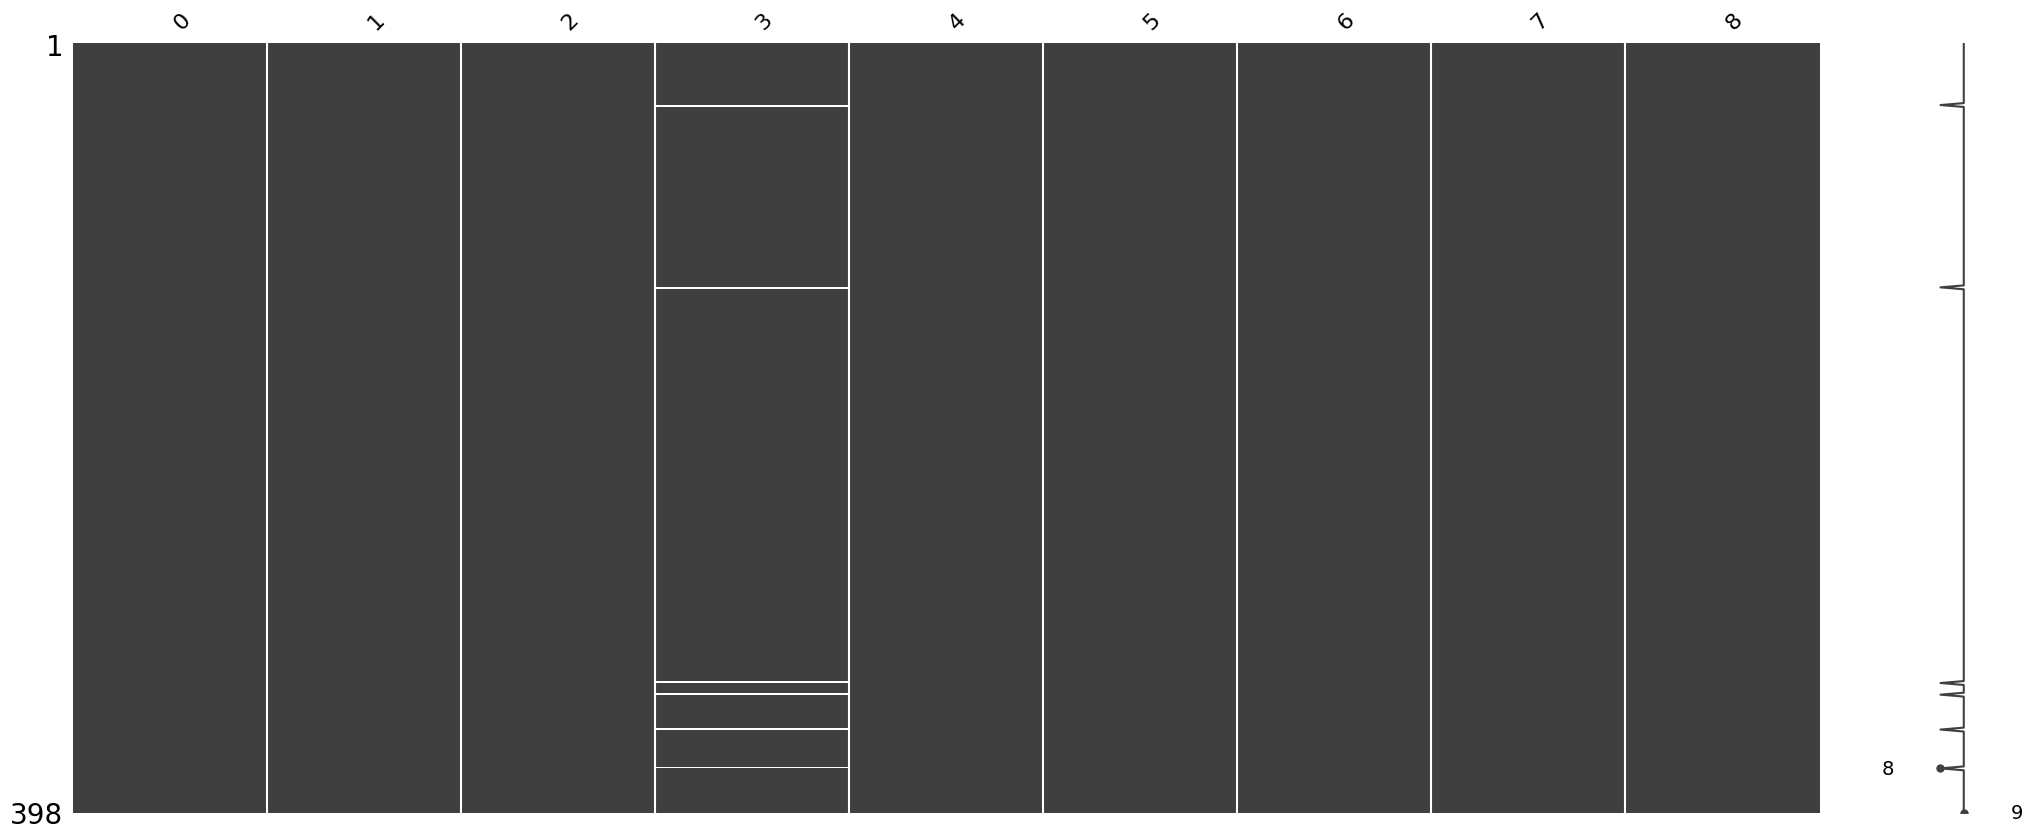

In [135]:
import missingno as msno
msno.matrix(df)

C:\Users\sally\AppData\Local\Temp\ipykernel_21388\1326693455.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3] = df[3].astype('float')


<Axes: >

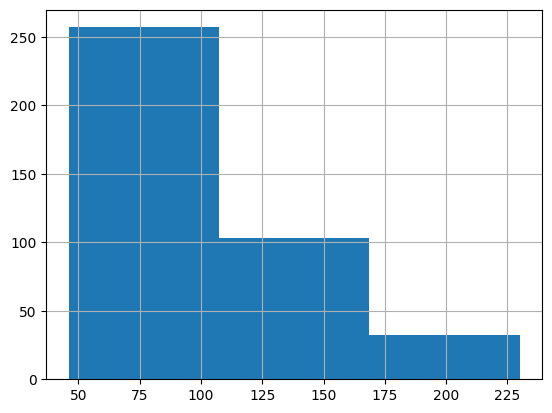

In [136]:
# 결측치 제거
df = df.dropna()
df[3] = df[3].astype('float')
df[3].hist(bins=3)


In [137]:
# 구간을 직접 지정  pd.cut  Domain 지식이 있을때... 
# 마력 low/ medium /hight
import numpy as np
cnt,bins = np.histogram(df[3],bins=3)
print(cnt, bins)
labels = ['low','midium','hight']
df['power'] = pd.cut(df[3],
    bins = bins,
    labels = labels
)
df.head()

[257 103  32] [ 46.         107.33333333 168.66666667 230.        ]


C:\Users\sally\AppData\Local\Temp\ipykernel_21388\1176588988.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['power'] = pd.cut(df[3],


,0,1,2,3,4,5,6,7,8,power
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,midium
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,midium
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,midium
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,midium
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,midium


In [138]:
# pd.qcut  분위수기반으로 동일한 개수로 분할
# 각 구간별 샘플개수가 비슷
# 구간폭이 일정하지 않음
labels = ['low','midium','hight']
df['qpower'] = pd.qcut(df[3],q=3,labels=labels)
df.head()

C:\Users\sally\AppData\Local\Temp\ipykernel_21388\261830568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['qpower'] = pd.qcut(df[3],q=3,labels=labels)


,0,1,2,3,4,5,6,7,8,power,qpower
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,midium,hight
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,midium,hight
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,midium,hight
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,midium,hight
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,midium,hight


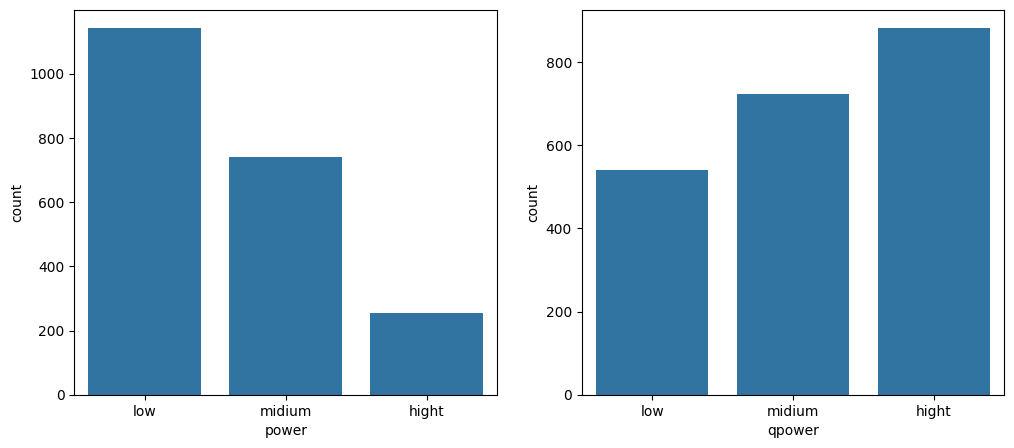

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
f,ax = plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df,x='power',ax=ax[0])
sns.countplot(data=df,x='qpower',ax=ax[1])
plt.show()

In [140]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# horsepower 열의 누락 데이터('?') 삭제하고 실수형으로 변환
df['horsepower'] = df['horsepower'].replace('?', np.nan)      # '?'을 np.nan으로 변경
df = df.dropna(subset=['horsepower'], axis=0)                 # 누락데이터 행을 삭제
df['horsepower'] = df['horsepower'].astype('float')           # 문자열을 실수형으로 변환

# np.histogram 함수로 3개의 bin으로 나누는 경계 값의 리스트 구하기
count, bin_dividers = np.histogram(df['horsepower'], bins=3)    # 세 구간으로 나누기
print(bin_dividers) 

[ 46.         107.33333333 168.66666667 230.        ]


In [141]:
# 3개의 bin에 이름 지정
bin_names = ['저출력', '보통출력', '고출력']

# pd.cut 함수로 각 데이터를 3개의 bin에 할당
df['hp_bin'] = pd.cut(x=df['horsepower'],     # 데이터 배열
                      bins=bin_dividers,      # 경계 값 리스트
                      labels=bin_names,       # bin 이름
                      include_lowest=True)    # 첫 경계값 포함 

# horsepower 열, hp_bin 열의 첫 15행을 출력
df[['horsepower', 'hp_bin']].head(15)

,horsepower,hp_bin
0,130.0,보통출력
1,165.0,보통출력
2,150.0,보통출력
3,150.0,보통출력
4,140.0,보통출력
5,198.0,고출력
6,220.0,고출력
7,215.0,고출력
8,225.0,고출력
9,190.0,고출력
